In [1]:
import numpy as np
import matplotlib.pyplot as plt
from objprint import op
from PIL import Image
from tqdm import tqdm
import sys
sys.path.append("/home/arno/Projects/Pint3D/print_ngp/util")

import printer.printerICM as icm


In [2]:
arrayPath="/home/arno/Projects/Pint3D/print_data/Gau/lego_crop/array/allData.npy"
volume=np.load(arrayPath)

volume.shape

(1428, 214, 767, 4)

In [42]:
volume_icc=np.zeros((volume.shape[0],volume.shape[1],volume.shape[2],4))
for i in tqdm(range(volume.shape[0]),desc="icc correcting..."):
    slice=volume[i]
    rgb_slice = slice.copy()
    rgb_slice[:, :, 0] = slice[:, :, 2]  # R = B
    rgb_slice[:, :, 2] = slice[:, :, 0]  # B = R
    # G通道保持不变
    slice = (rgb_slice * 255).astype(np.uint8)
    img = Image.fromarray(slice)
    output_files = icm.convert_color_profile(
        img,
        modes=[1],
        srgb_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc",
        cmyk_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",
        output_mode="CMYK",
        save_files=False
    )
    volume_icc[i]=np.array(output_files[0])

icc correcting...: 100%|██████████| 1428/1428 [00:36<00:00, 39.02it/s]


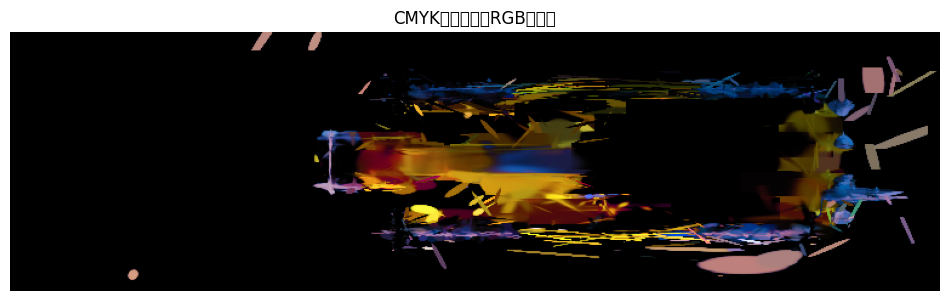

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

# 获取CMYK切片
cmyk_slice = volume_icc[300]  # 形状为(214, 767, 4)

# 确保数据类型正确
if cmyk_slice.dtype != np.uint8:
    if cmyk_slice.max() <= 255.0:
        cmyk_slice = cmyk_slice.astype(np.uint8)
    else:
        cmyk_slice = (cmyk_slice / cmyk_slice.max() * 255).astype(np.uint8)

# 创建CMYK模式的PIL图像
cmyk_img = Image.fromarray(cmyk_slice, mode='CMYK')

# 方法1：转换为RGB后显示
rgb_img = cmyk_img.convert('RGB')
plt.figure(figsize=(12, 8))
plt.imshow(rgb_img)
plt.title("CMYK图像转换为RGB后显示")
plt.axis('off')
plt.show()

无用但不要删除：展示采样的结果

/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26681 (\N{CJK UNIFIED IDEOGRAPH-6839}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arno/conda/envs/print3DNerfCUDA124/lib/python3.11/

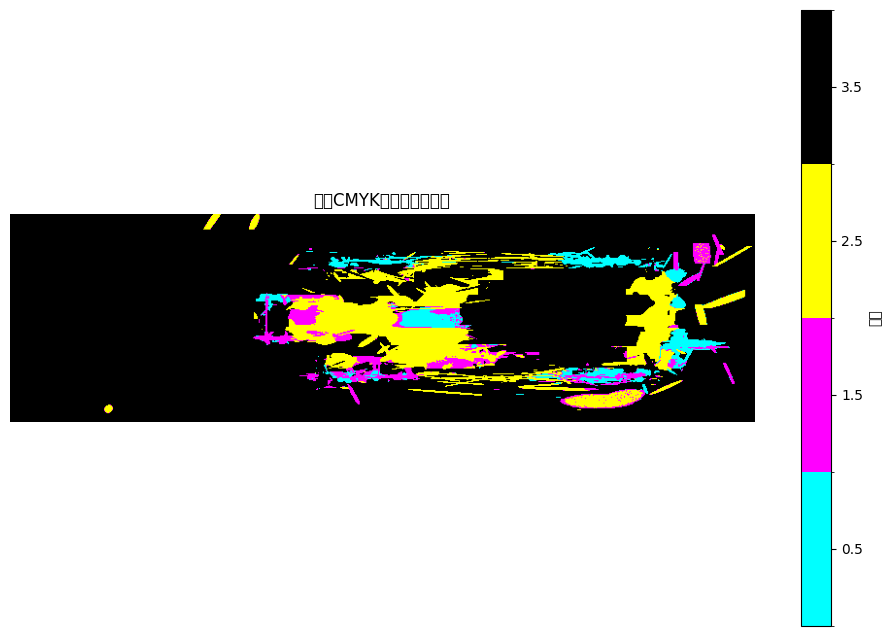

/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 38738 (\N{CJK UNIFIED IDEOGRAPH-9752}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_32237/2003602757.py:60: UserWarning: Glyph 40644 (\N{CJK UNIFIED IDEOGRAP

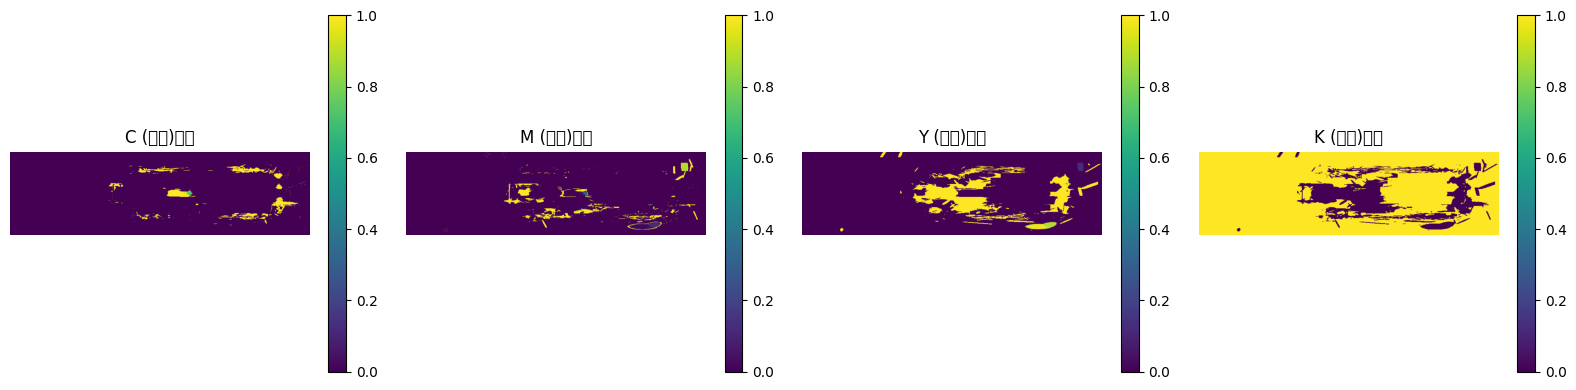

In [47]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 获取CMYK切片
cmyk_slice = volume_icc[300]  # 形状为(214, 767, 4)

# 确保数据为浮点型以便进行softmax计算
cmyk_float = cmyk_slice.astype(np.float32)

# 计算softmax概率
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=2, keepdims=True))
    return e_x / np.sum(e_x, axis=2, keepdims=True)

# 对每个像素应用softmax
cmyk_probs = softmax(cmyk_float)

# 创建采样结果数组
height, width, channels = cmyk_slice.shape
sampled_image = np.zeros((height, width), dtype=np.uint8)

# 对每个像素根据概率采样
for i in range(height):
    for j in range(width):
        # 获取当前像素的CMYK概率
        pixel_probs = cmyk_probs[i, j]
        
        # 根据概率采样一个通道 (0=C, 1=M, 2=Y, 3=K)
        sampled_channel = np.random.choice([0, 1, 2, 3], p=pixel_probs)
        
        # 将采样结果存储到结果图像中
        # 这里我们用0-3表示不同通道
        sampled_image[i, j] = sampled_channel

# 可视化采样结果
# 创建一个颜色映射，将0,1,2,3映射到CMYK对应的颜色
cmap = plt.cm.colors.ListedColormap(['cyan', 'magenta', 'yellow', 'black'])
bounds = [0, 1, 2, 3, 4]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(12, 8))
plt.imshow(sampled_image, cmap=cmap, norm=norm)
plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5], label='通道')
plt.clim(-0.5, 3.5)
plt.title('根据CMYK概率采样的结果')
plt.axis('off')
plt.show()

# 也可以显示原始的概率分布
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
channel_names = ['C (青色)', 'M (品红)', 'Y (黄色)', 'K (黑色)']

for i in range(4):
    im = axes[i].imshow(cmyk_probs[:, :, i], cmap='viridis')
    axes[i].set_title(f'{channel_names[i]}概率')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

numpy加速采样

In [49]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=2, keepdims=True))
    return e_x / np.sum(e_x, axis=2, keepdims=True)

def process_slice_vectorized(slice):
    # 确保数据为浮点型以便进行softmax计算
    cmyk_float = slice.astype(np.float32)
    
    # 对每个像素应用softmax
    cmyk_probs = softmax(cmyk_float)
    
    # 获取形状
    height, width, channels = slice.shape
    
    # 为每个像素生成一个随机数
    random_values = np.random.random((height, width, 1))
    
    # 创建累积概率分布
    cumulative_probs = np.cumsum(cmyk_probs, axis=2)
    
    # 初始化结果数组
    sampled_image = np.zeros((height, width), dtype=np.uint8)
    
    # 使用广播比较随机值和累积概率
    for channel in range(channels):
        if channel == 0:
            mask = random_values <= cumulative_probs[:, :, 0:1]
        else:
            mask = (random_values > cumulative_probs[:, :, channel-1:channel]) & (random_values <= cumulative_probs[:, :, channel:channel+1])
        sampled_image[mask[:, :, 0]] = channel
    
    return sampled_image

# 主处理循环
volume_icc_halftone = np.zeros((volume_icc.shape[0], volume_icc.shape[1], volume_icc.shape[2]), dtype=np.uint8)
for i in tqdm(range(volume_icc.shape[0]), desc="halftone correcting..."):
    slice = volume_icc[i]
    volume_icc_halftone[i] = process_slice_vectorized(slice)


halftone correcting...: 100%|██████████| 1428/1428 [00:17<00:00, 79.48it/s]


检查正确性（和上面应该一样），或者保存所有切片

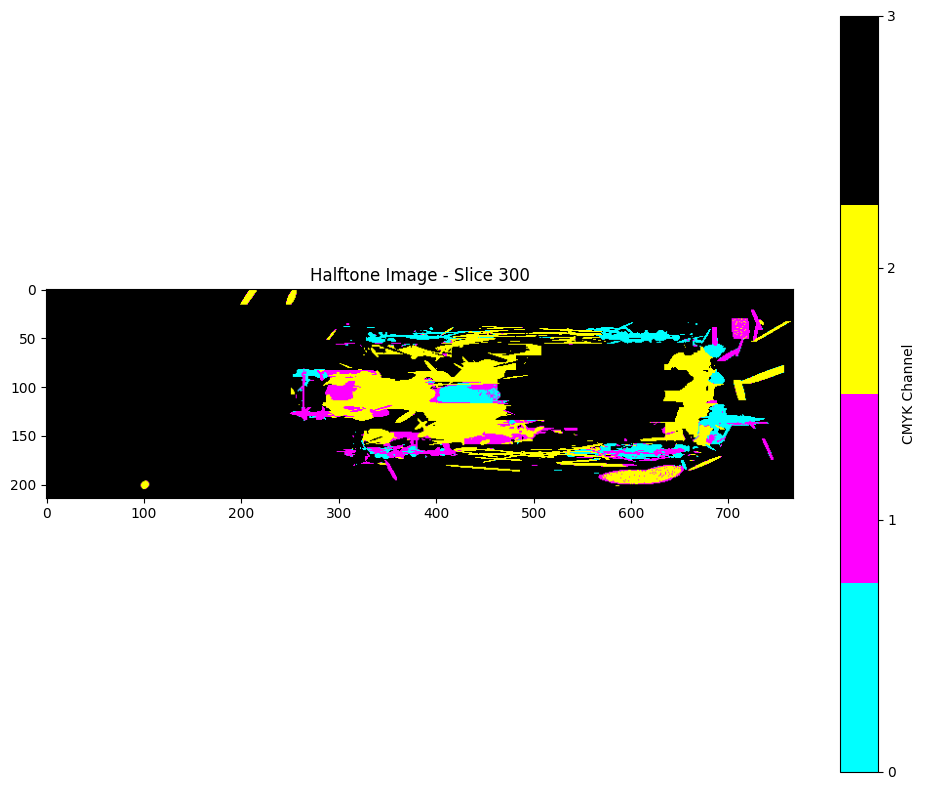

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

# 假设volume_icc_halftone已经通过之前的代码生成，包含0-3的值表示CMYK

# 创建CMYK颜色映射
# 青色(Cyan)、品红(Magenta)、黄色(Yellow)、黑色(Key/Black)
cmyk_colors = [
    [0, 1, 1],    # 青色 (C) - RGB(0, 255, 255)
    [1, 0, 1],    # 品红 (M) - RGB(255, 0, 255)
    [1, 1, 0],    # 黄色 (Y) - RGB(255, 255, 0)
    [0, 0, 0]     # 黑色 (K) - RGB(0, 0, 0)
]
cmyk_cmap = ListedColormap(cmyk_colors)

# 可视化单个切片
def visualize_halftone_slice(slice_idx):
    plt.figure(figsize=(10, 8))
    plt.imshow(volume_icc_halftone[slice_idx], cmap=cmyk_cmap)
    plt.colorbar(ticks=[0, 1, 2, 3], label='CMYK Channel')
    plt.title(f'Halftone Image - Slice {slice_idx}')
    plt.tight_layout()
    plt.show()

# 示例：可视化第一个切片
visualize_halftone_slice(300)

# 保存所有切片为图像文件
def save_all_halftone_slices(output_dir="./halftone_images/"):
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    for i in tqdm(range(volume_icc_halftone.shape[0]), desc="Saving halftone images"):
        plt.figure(figsize=(10, 8))
        plt.imshow(volume_icc_halftone[i], cmap=cmyk_cmap)
        plt.colorbar(ticks=[0, 1, 2, 3], label='CMYK Channel')
        plt.title(f'Halftone Image - Slice {i}')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/halftone_slice_{i:03d}.png", dpi=150)
        plt.close()

# 取消注释以保存所有切片
# save_all_halftone_slices()
